<a href="https://colab.research.google.com/github/sks-007/ML/blob/main/day24Standardisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import numpy as np
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
df=pd.read_csv('/Social_Network_Ads.csv')

In [109]:
df=df.iloc[:,2:]

In [110]:
df.sample(5)

,Age,EstimatedSalary,Purchased
287,48,138000,1
96,35,25000,0
368,38,71000,0
182,32,117000,1
311,39,96000,1


Train test split

In [111]:
from sklearn.model_selection import train_test_split

In [112]:
xtrain, xtest, ytrain, ytest = train_test_split(
   df.drop('Purchased', axis=1),
   df['Purchased'],
   test_size=0.3,
   random_state=0
)

In [113]:
xtrain.shape, xtest.shape

((280, 2), (120, 2))


StandardScaler

In [114]:
from sklearn.preprocessing import StandardScaler

In [115]:
scaler = StandardScaler()

In [116]:
scaler.fit(xtrain)

StandardScaler()

In [117]:
# scaler.fit(X_test)

# Why NOT fit on test data?
# 👉 This causes data leakage
# 👉 Model indirectly sees test data

In [118]:
# Correct Flow (VERY IMPORTANT)
# fit → only on training data
# transform → on both train and test

In [119]:
xtest_scaled=scaler.transform(xtest)

In [120]:
xtest_scaled

array([[-0.77101313,  0.49720103],
       [ 0.0133054 , -0.57280368],
       [-0.28081405,  0.15017248],
       [-0.77101313,  0.26584866],
       [-0.28081405, -0.57280368],
       [-1.06513258, -1.44037507],
       [-0.67297331, -1.5849703 ],
       [-0.18277423,  2.14558666],
       [-1.94749093, -0.05226085],
       [ 0.89566375, -0.775237  ],
       [-0.77101313, -0.60172273],
       [-0.96709276, -0.42820845],
       [-0.08473441, -0.42820845],
       [ 0.11134522,  0.20801057],
       [-1.7514113 ,  0.46828198],
       [-0.5749335 ,  1.36477242],
       [-0.08473441,  0.20801057],
       [-1.84945111,  0.43936294],
       [ 1.67998229,  1.74072002],
       [-0.28081405, -1.38253697],
       [-0.28081405, -0.65956082],
       [ 0.89566375,  2.14558666],
       [ 0.30742485, -0.54388463],
       [ 0.89566375,  1.01774386],
       [-1.45729185, -1.2090227 ],
       [ 1.09174339,  2.05882953],
       [-0.96709276,  0.49720103],
       [-0.86905295,  0.29476771],
       [-0.08473441,

In [121]:
xtrain_scaled=scaler.transform(xtrain)

In [122]:
xtrain_scaled.shape

(280, 2)

In [123]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [124]:
xtrain

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [125]:
xtest

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000
...,...,...
216,49,65000
259,45,131000
49,31,89000
238,46,82000


In [126]:
xtrain_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [127]:
xtrain_scaled=pd.DataFrame(xtrain_scaled, columns=xtrain.columns)
xtest_scaled=pd.DataFrame(xtest_scaled, columns=xtest.columns)

In [128]:
xtrain_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [129]:
xtest_scaled

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804
...,...,...
115,1.091743,-0.139018
116,0.699584,1.769639
117,-0.672973,0.555039
118,0.797624,0.352606


After scaling, data becomes a NumPy array, so we convert it back to DataFrame to retain column names.

In [130]:
xtrain.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [131]:
np.round(xtrain.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [132]:
xtrain_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


In [133]:
np.round(xtrain_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3



Effect of Scaling

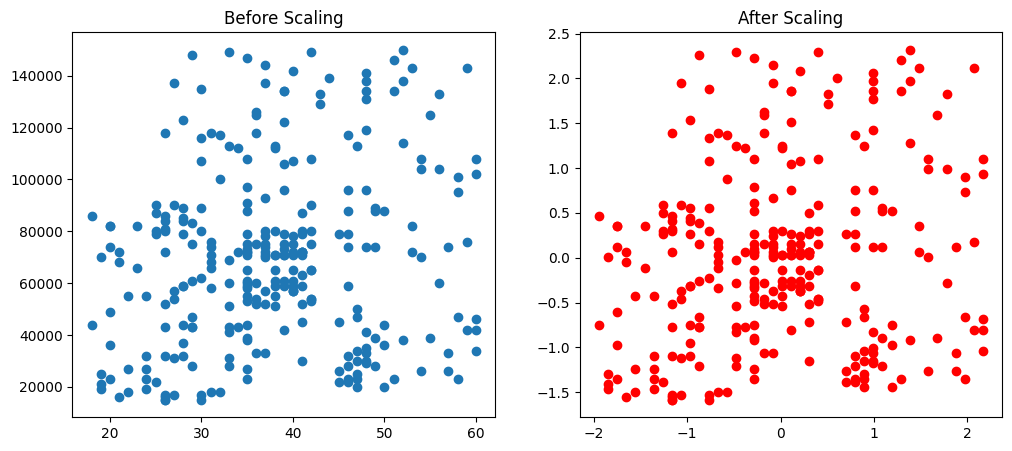

In [134]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(xtrain['Age'], xtrain['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(xtrain_scaled['Age'], xtrain_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

Text(0.5, 1.0, 'Before Scaling')

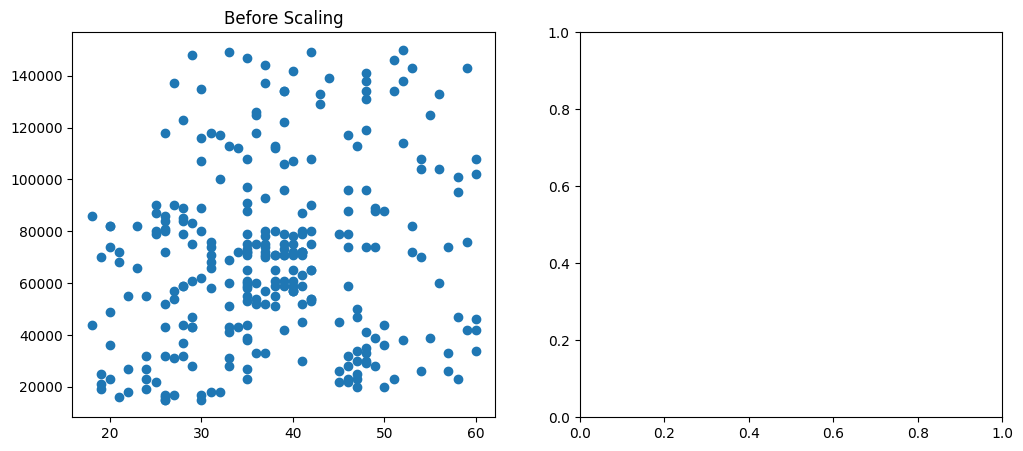

In [135]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(xtrain['Age'], xtrain['EstimatedSalary'])
ax1.set_title("Before Scaling")

In [136]:
ax1.scatter(xtrain['Age'], xtrain['EstimatedSalary'])
ax1.set_title("Before Scaling")

Text(0.5, 1.0, 'Before Scaling')

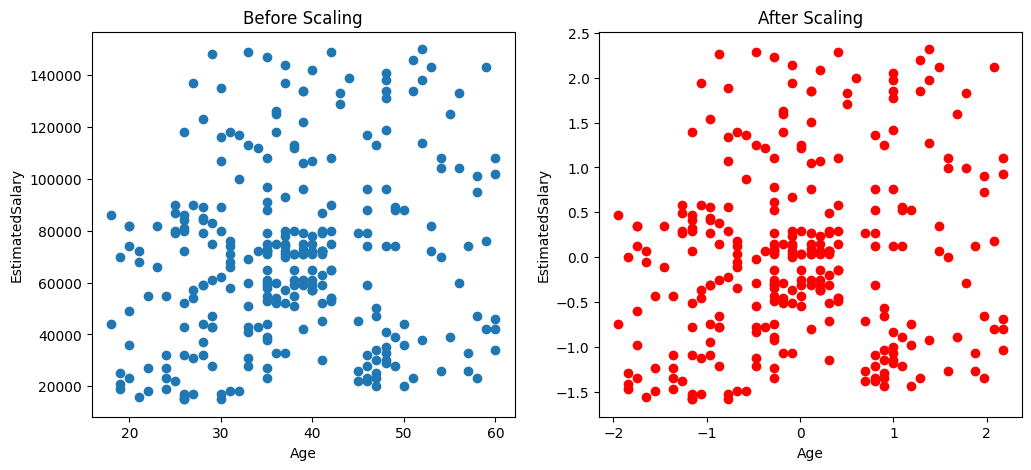

In [137]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(xtrain['Age'], xtrain['EstimatedSalary'])
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")
ax1.set_title("Before Scaling")


ax2.scatter(xtrain_scaled['Age'], xtrain_scaled['EstimatedSalary'], color='red')
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")
ax2.set_title("After Scaling")
plt.show()

In [138]:
ax2.scatter(xtrain_scaled['Age'], xtrain_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")

Text(0.5, 1.0, 'After Scaling')

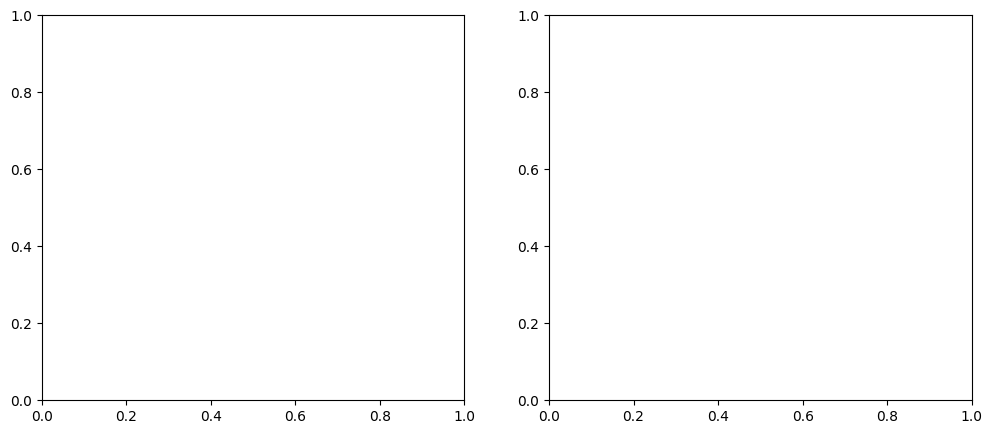

In [139]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

<Axes: title={'center': 'After Standard Scaling'}, xlabel='Age', ylabel='Density'>

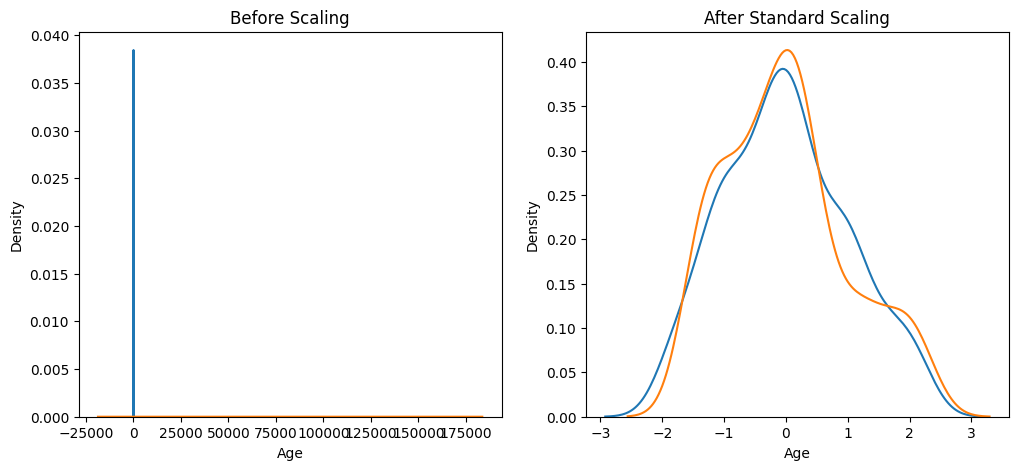

In [140]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(xtrain['Age'], ax=ax1)
sns.kdeplot(xtrain['EstimatedSalary'], ax=ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(xtrain_scaled['Age'], ax=ax2)
sns.kdeplot(xtrain_scaled['EstimatedSalary'], ax=ax2)

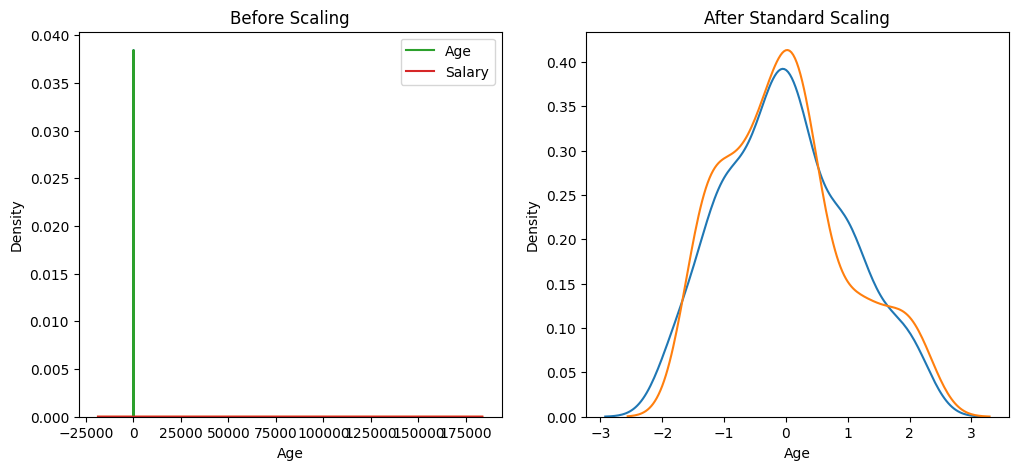

In [141]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(xtrain['Age'], ax=ax1)
sns.kdeplot(xtrain['EstimatedSalary'], ax=ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(xtrain_scaled['Age'], ax=ax2)
sns.kdeplot(xtrain_scaled['EstimatedSalary'], ax=ax2)

sns.kdeplot(xtrain['Age'], ax=ax1, label='Age')
sns.kdeplot(xtrain['EstimatedSalary'], ax=ax1, label='Salary')
ax1.legend()

Why scaling is important?

In [142]:
from sklearn.linear_model import LogisticRegression

In [143]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [144]:
lr.fit(xtrain,ytrain)
lr_scaled.fit(xtrain_scaled,ytrain)

LogisticRegression()

.fit() means:

“Train the model using given data”

Internally, model:

Finds patterns
Learns weights (coefficients)

In [145]:
y_pred = lr.predict(xtest)
y_pred_scaled = lr_scaled.predict(xtest_scaled)

👉 .predict() means:

“Use learned model to predict output for new data”

In [146]:
from sklearn.metrics import accuracy_score

In [147]:
print("Actual",accuracy_score(ytest,y_pred))
print("Scaled",accuracy_score(ytest,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


Q: Does scaling always improve accuracy?

👉 Answer:

No, scaling does not always improve accuracy. It mainly helps in faster convergence and better model stability, especially for distance-based algorithms.

In [148]:

from sklearn.tree import DecisionTreeClassifier

In [149]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [150]:
dt.fit(xtrain,xtrain)
dt_scaled.fit(xtrain_scaled,xtrain)

DecisionTreeClassifier()

In [151]:
y_pred = dt.predict(xtest)
y_pred_scaled = dt_scaled.predict(xtest_scaled)

In [153]:
print("Actual", accuracy_score(ytest, y_pred))
print("Scaled", accuracy_score(ytest, y_pred_scaled))

ValueError: Classification metrics can't handle a mix of binary and multiclass-multioutput targets

In [154]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [157]:
df = pd.concat([
    df,
    pd.DataFrame({
        'Age': [5, 90, 95],
        'EstimatedSalary': [1000, 250000, 350000],
        'Purchased': [0, 1, 1]
    })
], ignore_index=True)

In [158]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


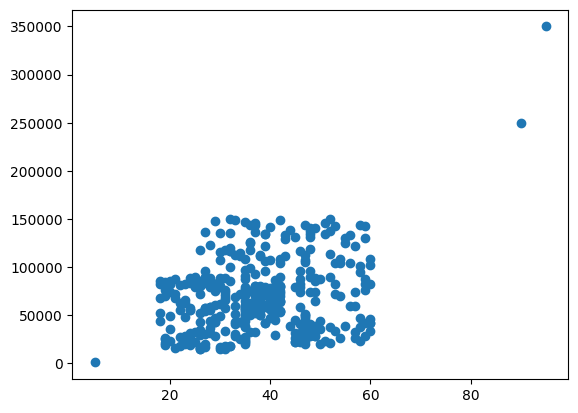

In [159]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [160]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

In [161]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [162]:

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

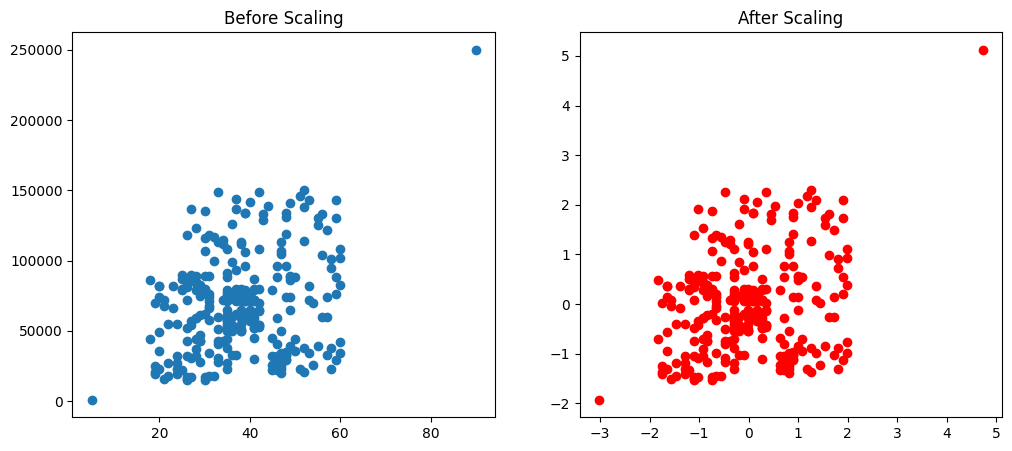

In [163]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()